# Desafio de Logística Olist

Notebook.

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../data/processed', exist_ok=True)

## 1. Carregamento e Verificação

In [10]:
treino = pd.read_csv('../data/train.csv')
teste = pd.read_csv('../data/test.csv')

print(f'Treino: {treino.shape}')
print(f'Teste: {teste.shape}')
display(treino.head())

Treino: (90177, 16)
Teste: (22473, 15)


,row_id,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,customer_state,customer_city
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,RJ,campos dos goytacazes
1,2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,3050.0,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,MG,para de minas
2,3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,200.0,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,SP,atibaia
3,4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,3750.0,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,SP,varzea paulista
4,5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,450.0,24.0,8.0,15.0,816cbea969fe5b689b39cfc97a506742,delivered,MG,uberaba


## 2. Preparação e Limpeza

In [11]:
colunas_dimensao = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in colunas_dimensao:
    treino[col] = treino[col].fillna(treino[col].median())
    teste[col] = teste[col].fillna(treino[col].median())

## 3. Engenharia de Atributos

In [12]:
def extrair_atributos(df):
    df['volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
    df['peso_cubado_g'] = (df['volume_cm3'] / 6000) * 1000
    df['peso_faturado_g'] = df[['product_weight_g', 'peso_cubado_g']].max(axis=1)
    df['densidade'] = df['product_weight_g'] / (df['volume_cm3'] + 1)
    df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])
    df['mes'] = df['shipping_limit_date'].dt.month
    return df

treino = extrair_atributos(treino)
teste = extrair_atributos(teste)

In [13]:
enc = LabelEncoder()
treino['customer_state_enc'] = enc.fit_transform(treino['customer_state'])
teste['customer_state_enc'] = enc.transform(teste['customer_state'])

vendedor_media = treino.groupby('seller_id')['freight_value'].mean().to_dict()
treino['seller_freight_avg'] = treino['seller_id'].map(vendedor_media)
teste['seller_freight_avg'] = teste['seller_id'].map(vendedor_media).fillna(treino['freight_value'].mean())

## 4. Avaliação de Métricas

In [14]:
features = ['price', 'product_weight_g', 'volume_cm3', 'peso_faturado_g', 'densidade', 'customer_state_enc', 'seller_freight_avg', 'mes']
X = treino[features]
y = np.log1p(treino['freight_value'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=67)

modelo = RandomForestRegressor(n_estimators=100, random_state=67, n_jobs=1)
modelo.fit(X_train, y_train)

preds_val = np.expm1(modelo.predict(X_val))
y_val_orig = np.expm1(y_val)

print(f'MAE: {mean_absolute_error(y_val_orig, preds_val):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_val_orig, preds_val)):.2f}')
print(f'R² Score: {r2_score(y_val_orig, preds_val):.2f}')

MAE: 3.56
RMSE: 7.83
R² Score: 0.74


### Visualização de Erros

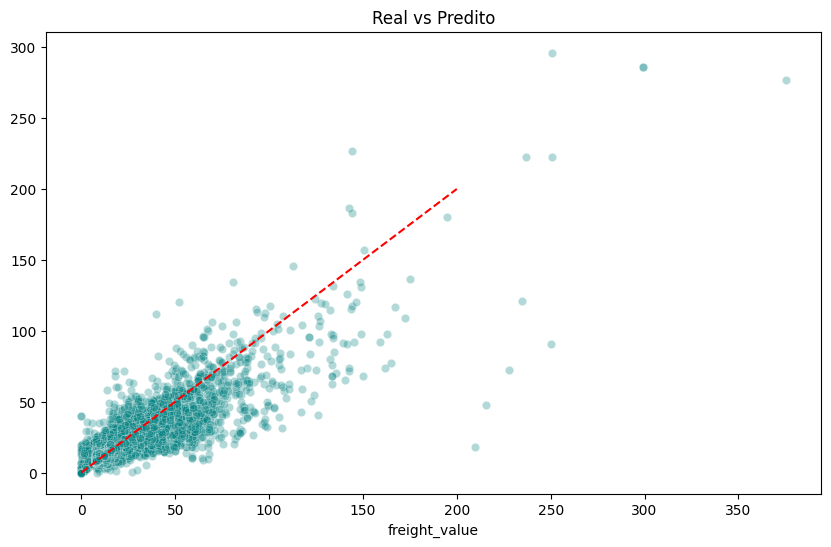

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_orig, y=preds_val, alpha=0.3, color='teal')
plt.plot([0, 200], [0, 200], '--r')
plt.title('Real vs Predito')
plt.show()

## 5. Segmentação e Exportação

In [16]:
km = KMeans(n_clusters=4, random_state=67, n_init=10)
treino['cluster'] = km.fit_predict(StandardScaler().fit_transform(treino[['price', 'freight_value', 'customer_state_enc']]))

modelo.fit(X, y)
preds_final = np.expm1(modelo.predict(teste[features]))
pd.DataFrame({'row_id': teste['row_id'], 'freight_value': preds_final}).to_csv('../data/processed/submission.csv', index=False)
treino.to_csv('../data/processed/train_processed.csv', index=False)